<a href="https://colab.research.google.com/github/Ashwin1934/PortfolioAnalysisMonorepo/blob/main/Model_08_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import torch
import torch.nn as nn
import pandas
import nltk
from sklearn.model_selection import train_test_split
import numpy
from time import perf_counter

Check that GPU is available in colab. Change runtime in between and observe the difference.

In [67]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
if torch.cuda.is_available():
  print(f"Number of GPUs: {torch.cuda.device_count()}")
  for i in range(torch.cuda.device_count()):
      print(f"\nGPU {i}:")
      print(f"  Name: {torch.cuda.get_device_name(i)}")
      print(f"  Total Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")
      print(f"  MultiProcessor Count: {torch.cuda.get_device_properties(i).multi_processor_count}")
      print(f"  CUDA Capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")

True
Tesla T4
Number of GPUs: 1

GPU 0:
  Name: Tesla T4
  Total Memory: 15.83 GB
  MultiProcessor Count: 40
  CUDA Capability: 7.5


In Google Colab, pytorch automatically uses the T4 GPU specified in the runtime. The below code will come in handy when training the model on a bare metal node. We can specify the GPU and move the model/data to the GPU. Pytorch will then automatically execute operations on the GPU.

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [69]:
df = pandas.read_csv('/content/all-data.csv', encoding='ISO-8859-1', header=None, names=["Sentiment", "Headline"])
df.head()

,Sentiment,Headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


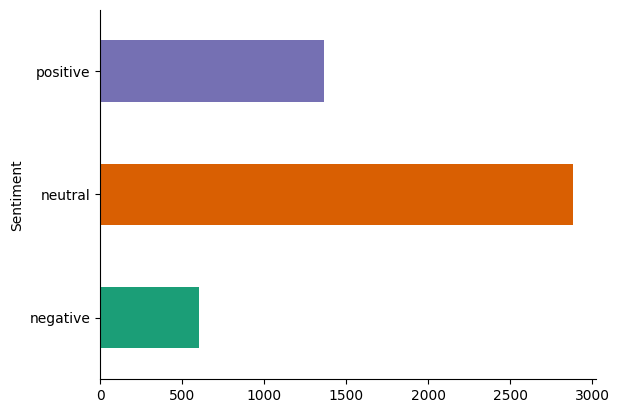

In [70]:
from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Sentiment').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [71]:
#lowercase
df['Headline'] = df['Headline'].str.lower()
df.info()

def remove_whitespaces(document):
  return " ".join(document.split())
df['Headline'] = df['Headline'].apply(remove_whitespaces)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4846 non-null   object
 1   Headline   4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


,Sentiment,Headline
0,neutral,"according to gran , the company has no plans t..."
1,neutral,technopolis plans to develop in stages an area...
2,negative,the international electronic industry company ...
3,positive,with the new production plant the company woul...
4,positive,according to the company 's updated strategy f...


In [72]:
nltk.download('punkt_tab')
from nltk import word_tokenize
df['Headline'] = df['Headline'].apply(lambda headline: word_tokenize(headline))

def categorize_sentiment(sentiment):
  if sentiment == 'positive':
    return 0
  elif sentiment == 'neutral':
    return 1
  elif sentiment == 'negative':
    return 2
  return 1

df['Label'] = df['Sentiment'].apply(lambda sentiment: categorize_sentiment(sentiment))
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Sentiment,Headline,Label
0,neutral,"[according, to, gran, ,, the, company, has, no...",1
1,neutral,"[technopolis, plans, to, develop, in, stages, ...",1
2,negative,"[the, international, electronic, industry, com...",2
3,positive,"[with, the, new, production, plant, the, compa...",0
4,positive,"[according, to, the, company, 's, updated, str...",0


In [73]:
#remove stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
english_stopwords = stopwords.words('english')

def remove_stopwords(document):
  result = []
  for token in document:
    if token not in english_stopwords:
      result.append(token)
  return result
df['Headline'] = df['Headline'].apply(remove_stopwords)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Sentiment,Headline,Label
0,neutral,"[according, gran, ,, company, plans, move, pro...",1
1,neutral,"[technopolis, plans, develop, stages, area, le...",1
2,negative,"[international, electronic, industry, company,...",2
3,positive,"[new, production, plant, company, would, incre...",0
4,positive,"[according, company, 's, updated, strategy, ye...",0


Now build the vocabulary (represents the feature space), create a wordToIdx dictionary so we can use it in our embeddings etc. Note we haven't used pretrained embeddings like glove here

In [74]:
from collections import Counter
vocabulary = set()
for headline in df['Headline']:
  for word in headline:
    vocabulary.add(word)

vocab = Counter(vocabulary)
vocab = sorted(vocab, key=vocab.get, reverse=True)
vocab_size = len(vocab)

word2idx = {word: index for index, word in enumerate(vocab)} #create a mreverse mapping

def create_index_representation_for_headline(headline):
  return [word2idx[word] for word in headline]

df['Headline Indices'] = df['Headline'].apply(create_index_representation_for_headline)
df.head()

,Sentiment,Headline,Label,Headline Indices
0,neutral,"[according, gran, ,, company, plans, move, pro...",1,"[4904, 11484, 1844, 7218, 2907, 3578, 1987, 45..."
1,neutral,"[technopolis, plans, develop, stages, area, le...",1,"[1162, 2907, 495, 6601, 7661, 356, 11466, 5665..."
2,negative,"[international, electronic, industry, company,...",2,"[8017, 11175, 5841, 7218, 3230, 2477, 7617, 11..."
3,positive,"[new, production, plant, company, would, incre...",0,"[10158, 1987, 7520, 7218, 143, 11192, 3506, 74..."
4,positive,"[according, company, 's, updated, strategy, ye...",0,"[4904, 7218, 11554, 6505, 8552, 3814, 2981, 18..."


Split the dataset into training and test groups

In [75]:
X_train, X_test, Y_train, Y_test = train_test_split(df['Headline Indices'], df['Label'], test_size=0.2)

X_train = numpy.array(X_train)
X_test = numpy.array(X_test)
y_train = numpy.array(Y_train)
y_test = numpy.array(Y_test)

In [76]:
print(len(X_train[0]))
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train[0])
print(word2idx["beat"])
print(len(X_train[0]), len(X_train[200]))

17
(3876,) (3876,)
(970,) (970,)
[10715, 1333, 7218, 1410, 10342, 9913, 4398, 3500, 403, 3871, 1844, 11444, 3500, 724, 10489, 10309, 9346]
5220
17 22


Define the model. Using LSTM to encode the headline. Then piping in the last hidden state as the input to a feed forward neural network and performing classification.

In [84]:
class EncoderDecoder(nn.Module):

  def __init__(self, embedding_dim, vocab_size, num_classes) -> None:
    super(EncoderDecoder, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embedding_dim=embedding_dim)
    self.lstm = nn.LSTM(embedding_dim, 50)

    self.linear = nn.Linear(50, num_classes)
    self.softmax = nn.Softmax(dim=0)
    self.logsoftmax = nn.LogSoftmax(dim = 0)

  def forward(self, headline):
    #print(headline.shape)
    embedding = self.embedding(headline)
    #print(embedding.shape)
    #add in average_embeddings to get a size [100] vector to represent each sentence with one embedding
    # average_embedding = embedding.mean(dim=0) # Remove this line
    #lstm_out = self.lstm(embedding)
    # lstm_out = self.lstm(average_embedding) # Remove this line
    lstm_out, (hidden, cell) = self.lstm(embedding) # Use the full embedding as input to LSTM
    #print(lstm_out.shape)
    #print(hidden.shape)
    #print(cell.shape)
    #encoded_lstm_out = lstm_out[:, -1, :] # Get the last hidden state from the output
    #print(encoded_lstm_out.shape)
    last_hidden = hidden[-1]

    linear = self.linear(last_hidden.squeeze(0)) # pass in hidden state to linear portion of network, this last hidden state is intended to represent the whole sentence
    #print(linear.shape)
    logsoftmax = self.logsoftmax(linear)
    #print("model output shape")
    #print(logsoftmax.shape)

    return logsoftmax

Noticed that torch.cuda.memory_allocated() was returning 0.0 MB in each epoch. This means the GPU is not being used for operations. We need to explicitly move the data/model over to the GPU. In the two subsequent cells we move the model to cuda and the training data to cuda.

In [85]:
num_classes=3
model = EncoderDecoder(embedding_dim=100, vocab_size=vocab_size, num_classes=num_classes).to(device)
print(model)

EncoderDecoder(
  (embedding): Embedding(11576, 100)
  (lstm): LSTM(100, 50)
  (linear): Linear(in_features=50, out_features=3, bias=True)
  (softmax): Softmax(dim=0)
  (logsoftmax): LogSoftmax(dim=0)
)


In [86]:
X_train_tensors = []
for headline_indicies in X_train:
  X_train_tensors.append(torch.tensor(headline_indicies, dtype=torch.long, device=device))
sample_row_output = model.forward(torch.tensor(X_train_tensors[0]))

/tmp/ipython-input-3959741638.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_row_output = model.forward(torch.tensor(X_train_tensors[0]))


In [87]:
print(len(X_train[0]))
print(sample_row_output[0].shape)
print(sample_row_output)
#print(sample_row_output[1][0].shape) used to log lstm output
# print(sample_row_output[1][1].shape)

17
torch.Size([])
tensor([-1.0856, -1.0598, -1.1528], device='cuda:0',
       grad_fn=<LogSoftmaxBackward0>)


In [89]:
# model training
from torch import optim
epochs = 8
optimizer = optim.Adam(model.parameters(), lr = 0.01)

start = perf_counter()
for x in range(epochs):

  total_loss = 0.0
  num_correct = 0

  for i in range(len(X_train_tensors)):

    headline = X_train_tensors[i]
    class_log_probs = model.forward(headline)
    #print(class_log_probs.shape)

    y_onehot = torch.zeros(num_classes).to(device)
    correct_label = y_train[i]
    y_onehot[correct_label] = 1

    predicted_label = torch.argmax(class_log_probs)

    if (correct_label == predicted_label):
      num_correct += 1

    loss = torch.neg(class_log_probs).dot(y_onehot)
    total_loss += loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print('------------------------')
  print(f'Finished epoch {x}, loss equals {total_loss}')
  accuracy = num_correct / len(X_train)
  print(f'Training accuracy: {accuracy}')
  print(f"Allocated Memory: {torch.cuda.memory_allocated() / 1e6:.2f} MB")
  print(f"Cached Memory: {torch.cuda.memory_reserved() / 1e6:.2f} MB")
end = perf_counter()


------------------------
Finished epoch 0, loss equals 2942.175048828125
Training accuracy: 0.6873065015479877
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 1, loss equals 2653.557861328125
Training accuracy: 0.7143962848297214
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 2, loss equals 2509.631103515625
Training accuracy: 0.7216202270381837
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 3, loss equals 2289.401123046875
Training accuracy: 0.7523219814241486
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 4, loss equals 2158.927490234375
Training accuracy: 0.7639318885448917
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finished epoch 5, loss equals 2003.447021484375
Training accuracy: 0.79437564499484
Allocated Memory: 59.86 MB
Cached Memory: 92.27 MB
------------------------
Finis

Training Execution Time With GPU. For context, the initial training time of the failed attempt on the CPU was 328 seconds.. I'm sure training could be parallelized to fully utilize all the CPU cores but that's not of interest here.

In [90]:
print(f"Execution Time: {end - start} seconds")

Execution Time: 68.93823084399992 seconds


Test Accuracy

In [91]:
X_test_tensors = []
for headline_indicies in X_test:
  X_test_tensors.append(torch.tensor(headline_indicies, dtype=torch.long, device=device))

In [92]:
num_correct = 0
for i in range(len(X_test)):
  class_log_probs = model.forward(torch.tensor(X_test_tensors[i]))
  correct_label = y_test[i] - 1
  predicted_label = torch.argmax(class_log_probs)

  if(correct_label == predicted_label):
    num_correct += 1

test_accuracy = num_correct / len(X_test)
print(f'Test accuracy: {test_accuracy}')

/tmp/ipython-input-2703553972.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_log_probs = model.forward(torch.tensor(X_test_tensors[i]))


Test accuracy: 0.21649484536082475


Save the model so we can use it later..

In [ ]:
lstm_ffnn = torch.save(model, 'lstm_ffnn.pt')
print('Model saved')